In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

In [16]:
# 1. Load data
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.shape)

(7043, 21)


In [17]:
# 2. Clean data
df = df.drop(columns=["customerID"])
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
print(df["Churn"].value_counts(normalize=True).round(3))

X = df.drop(columns=["Churn"])
y = df["Churn"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


In [18]:
# 3. Preprocessing
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
])

In [19]:
# 4. Models (class_weight handles the churn/non-churn imbalance)
models = {
    "Logistic Regression": Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "Random Forest": Pipeline([
        ("prep", preprocess),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                       random_state=42, n_jobs=-1)),
    ]),
}


===== Logistic Regression =====
Accuracy: 0.7381
ROC-AUC : 0.8413
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409


===== Random Forest =====
Accuracy: 0.7821
ROC-AUC : 0.8217
              precision    recall  f1-score   support

      Stayed       0.82      0.89      0.86      1035
     Churned       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



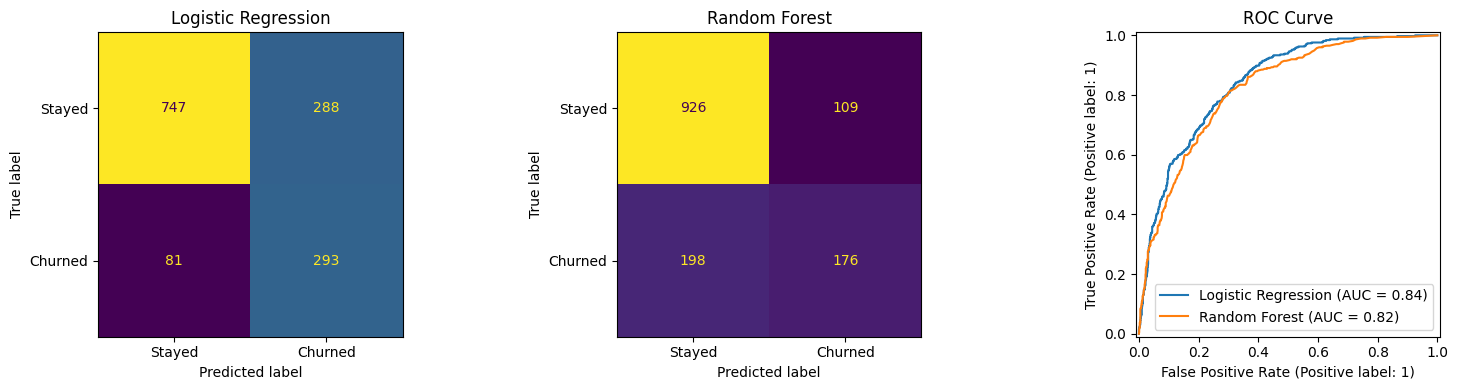

In [20]:
# 5. Split, train, evaluate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_test, preds), 4))
    print("ROC-AUC :", round(roc_auc_score(y_test, probs), 4))
    print(classification_report(y_test, preds, target_names=["Stayed", "Churned"]))
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                           display_labels=["Stayed", "Churned"]).plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)
    RocCurveDisplay.from_predictions(y_test, probs, ax=axes[2], name=name)
axes[2].set_title("ROC Curve")
plt.tight_layout()
plt.show()

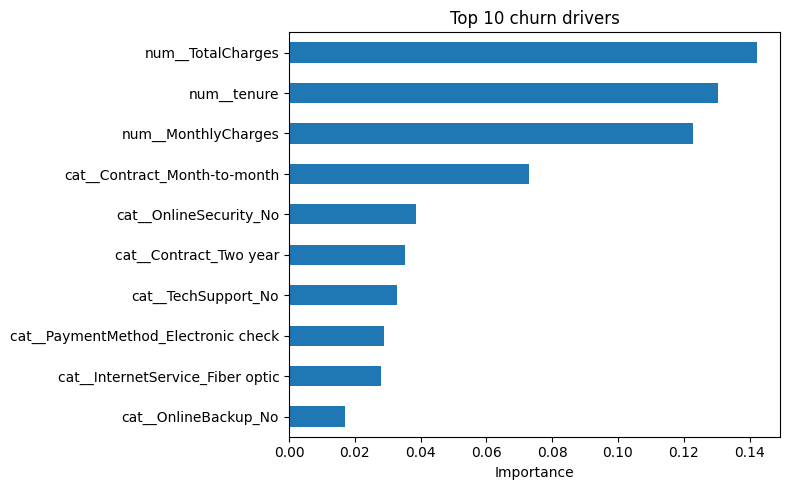

In [21]:
# 6. Key factors behind churn (Random Forest feature importance)
rf = models["Random Forest"]
feature_names = rf.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf.named_steps["clf"].feature_importances_, index=feature_names)
importances.sort_values().tail(10).plot(kind="barh", figsize=(8, 5), title="Top 10 churn drivers")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [22]:
# 7. Predict churn risk for a new customer
sample = X_test.iloc[[0]]
for name, model in models.items():
    p = model.predict_proba(sample)[0, 1]
    print(f"{name}: {p:.1%} chance of churn")

Logistic Regression: 11.5% chance of churn
Random Forest: 0.0% chance of churn
